#  E-Commerce Customer Churn Predictor (Version 1)

##  Why I Chose This Dataset?
Customer retention is very important for any e-commerce business. Finding a new customer is 5 times more costly than keeping an old one. I chose this dataset with 6,000 customer rows because it has good data about customer behavior, money spent, and satisfaction scores. It is perfect to practice my machine learning skills on a real business problem.

 **Important Note:** The original dataset did not have any target variable (like 'Churn'). So, I used rule-based feature engineering with Pandas to create our own 'Churn' column based on customer complaints and last purchase days. This makes the project more challenging and realistic!

##  How Features Will Help My ML Models:
1. **Recency & Frequency (`days_since_last_purchase`, `total_orders`):** If a customer is not buying anything from many days, the model will know they are losing interest.
2. **Customer Friction (`customer_support_tickets`, `return_rate`):** More complaints and returns mean the customer is unhappy and can leave the platform soon.
3. **Satisfaction (`satisfaction_score`, `loyalty_member`):** Low ratings show direct anger of the customer.
4. **Price Focus (`price_sensitivity_index`, `discount_usage_rate`):** This helps to find people who only buy when there is a discount and leave when prices go up.

### 📋 Customer Churn Dataset: Feature Dictionary

| Column Name | Data Type | Simple Meaning | How it Helps the ML Model?  |
| :--- | :--- | :--- | :--- |
| **Customer_ID** | Object | A unique identification number for each customer. | Must be dropped before training; it has no predictive power for the model. |
| **account_age_months** | Int64 | Number of months the customer has been registered with us. | Older, loyal customers generally have a much lower probability of churning. |
| **avg_order_value** | Float64 | The average amount of money a customer spends per order. | Helps identify high-value customers; losing them impacts business revenue heavily.  |
| **total_orders** | Int64 | The total number of purchases made by the customer so far. | Frequent buyers show loyalty, while low-order customers are at a higher risk of leaving. |
| **days_since_last_purchase** | Int64 | Number of days since the customer last made a purchase. |  **Critical Feature!** High inactivity (e.g., 90+ days) strongly indicates a high churn risk. |
| **discount_usage_rate** | Float64 | The ratio of orders placed using a discount or coupon code. | Identifies deal-seekers who might leave as soon as promotional offers end.  |
| **return_rate** | Float64 | The percentage of purchased items that the customer returns. | High return rates signal product dissatisfaction or potential fraudulent behavior. |
| **customer_support_tickets** | Int64 | Number of support or complaint tickets raised by the customer recently. |  **Hot Feature!** More complaints indicate a frustrated customer who is likely to churn. |
| **loyalty_member** | Object | Indicates if the customer has a premium/loyalty membership (Yes/No). | Premium members enjoy exclusive perks, resulting in a very low churn rate. |
| **browsing_frequency_per_week** | Float64 | Number of times the customer opens the app/website weekly just to browse. | A drop in browsing frequency indicates a loss of interest in the platform. |
| **cart_abandonment_rate** | Float64 | How often the customer adds items to the cart but leaves without purchasing. | High rates highlight friction in pricing, shipping costs, or checkout experience. 🛒 |
| **product_review_score_avg** | Float64 | The average star rating (1 to 5) the customer gives to products. | Low ratings indicate unhappy customers who might switch to a competitor.  |
| **engagement_score** | Float64 | Activity score calculated by the system based on clicks, scrolls, and time spent. | High engagement means a healthy relationship; low engagement signals detachment. |
| **satisfaction_score** | Float64 | The direct feedback score given by the customer to the overall service. | Direct sentiment indicator; a low score is a clear warning sign of impending churn. |
| **price_sensitivity_index** | Float64 | Metric showing how sensitive the customer is to price changes (Higher = more sensitive). | Highly sensitive users leave quickly if prices increase or discounts disappear.  |


### phase 1:
1. importing Libraries
2. Load DataSet
3. Analysing Data (Get INFO part of EDA) 
4. Statistical View of Data (describe the Data part of EDA)
5. Feature engg
5. EDA with Plots
6. Understanding Features based on EDA

In [38]:
# import some usefull Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [39]:
# load the data
df= pd.read_csv("W:\Data_Science\Projects\E_com_customer_Churn\ecommerce_customer_features.csv")
df.head()

,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6000 non-null   object 
 1   account_age_months           6000 non-null   int64  
 2   avg_order_value              6000 non-null   float64
 3   total_orders                 6000 non-null   int64  
 4   days_since_last_purchase     6000 non-null   int64  
 5   discount_usage_rate          6000 non-null   float64
 6   return_rate                  6000 non-null   float64
 7   customer_support_tickets     6000 non-null   int64  
 8   loyalty_member               6000 non-null   object 
 9   browsing_frequency_per_week  6000 non-null   float64
 10  cart_abandonment_rate        6000 non-null   float64
 11  product_review_score_avg     6000 non-null   float64
 12  engagement_score             6000 non-null   float64
 13  satisfaction_score

In [41]:
df.duplicated().sum()
# After analyzing we knew that there null and duplicated values are 0

np.int64(0)

In [42]:
# statistical view of data
df.describe()

,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index
count,6000.000000,6000.000000,6000.00000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,30.806667,80.487945,8.56750,29.598167,0.285057,0.071519,0.857667,3.076683,0.602106,3.879603,4.883687,8.069722,4.513517
std,17.358115,55.044707,9.88833,29.452645,0.158112,0.065077,0.977702,1.893899,0.201053,0.776396,1.479473,1.241928,1.150608
min,1.000000,10.000000,1.00000,0.000000,0.003000,0.000000,0.000000,0.000000,0.032000,1.000000,1.000000,2.300000,1.000000
25%,16.000000,44.525000,1.00000,9.000000,0.162000,0.022400,0.000000,1.600000,0.455000,3.350000,4.080000,7.320000,3.600000
50%,31.000000,67.225000,5.00000,20.000000,0.265000,0.052800,1.000000,3.000000,0.615000,3.920000,5.120000,8.230000,4.400000
75%,46.000000,100.685000,13.00000,41.000000,0.387000,0.102400,1.000000,4.400000,0.763000,4.490000,5.930000,9.000000,5.200000
max,60.000000,1006.530000,85.00000,261.000000,0.895000,0.493600,6.000000,10.300000,0.999000,5.000000,8.720000,10.000000,8.600000


In [43]:
# Feature Engg
df.drop("Customer_ID", axis= 1, inplace= True)
df["loyalty_member"]= df["loyalty_member"].map({"No": 0, "Yes": 1})

In [44]:
#creating Target Feature
risk= (
    (df["return_rate"]* 10.0)+
    (df["cart_abandonment_rate"]* 5.0)+
    (df["customer_support_tickets"]* .834)+
    (df["days_since_last_purchase"]* .02)-
    (df["engagement_score"]* 0.5)-
    (df["satisfaction_score"]* 0.5)
)
trashold= np.percentile(risk, 75)
df["chunk"]= np.where(risk> trashold, 1, 0)

In [45]:
df["chunk"]

0       0
1       0
2       0
3       0
4       0
       ..
5995    0
5996    0
5997    0
5998    0
5999    1
Name: chunk, Length: 6000, dtype: int64

In [46]:
# add some noice to avoid overfitting
np.random.seed(42)
noise_mask = np.random.rand(len(df)) < 0.15
df["chunk"]= np.where(noise_mask, 1- df["chunk"], df["chunk"])

In [47]:
df.head()

,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,chunk
0,46,164.96,12,17,0.243,0.1720,0,0,6.1,0.430,5.00,6.58,9.43,3.7,0
1,3,39.09,4,5,0.591,0.0808,1,0,4.1,0.183,4.44,6.25,8.50,6.9,0
2,29,37.42,8,47,0.212,0.1424,0,0,1.2,0.426,3.87,3.32,8.40,4.3,0
3,35,62.64,9,3,0.699,0.0128,0,0,3.8,0.730,4.75,6.42,9.71,7.5,0
4,39,113.03,1,7,0.382,0.0232,0,0,5.4,0.613,5.00,6.48,9.92,5.0,0


In [48]:
# Fixing Typo Error
df.rename({"chunk": "churn"}, axis= 1, inplace= True)

In [49]:
print("Target Variable Distribution")
print(df['churn'].value_counts())
print("\nPercentage:\n", df['churn'].value_counts(normalize=True) * 100)

Target Variable Distribution
churn
0    4029
1    1971
Name: count, dtype: int64

Percentage:
 churn
0    67.15
1    32.85
Name: proportion, dtype: float64


In [50]:
df.head()

,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churn
0,46,164.96,12,17,0.243,0.1720,0,0,6.1,0.430,5.00,6.58,9.43,3.7,0
1,3,39.09,4,5,0.591,0.0808,1,0,4.1,0.183,4.44,6.25,8.50,6.9,0
2,29,37.42,8,47,0.212,0.1424,0,0,1.2,0.426,3.87,3.32,8.40,4.3,0
3,35,62.64,9,3,0.699,0.0128,0,0,3.8,0.730,4.75,6.42,9.71,7.5,0
4,39,113.03,1,7,0.382,0.0232,0,0,5.4,0.613,5.00,6.48,9.92,5.0,0


In [51]:
sns.set_theme(context= "notebook", style= "darkgrid")

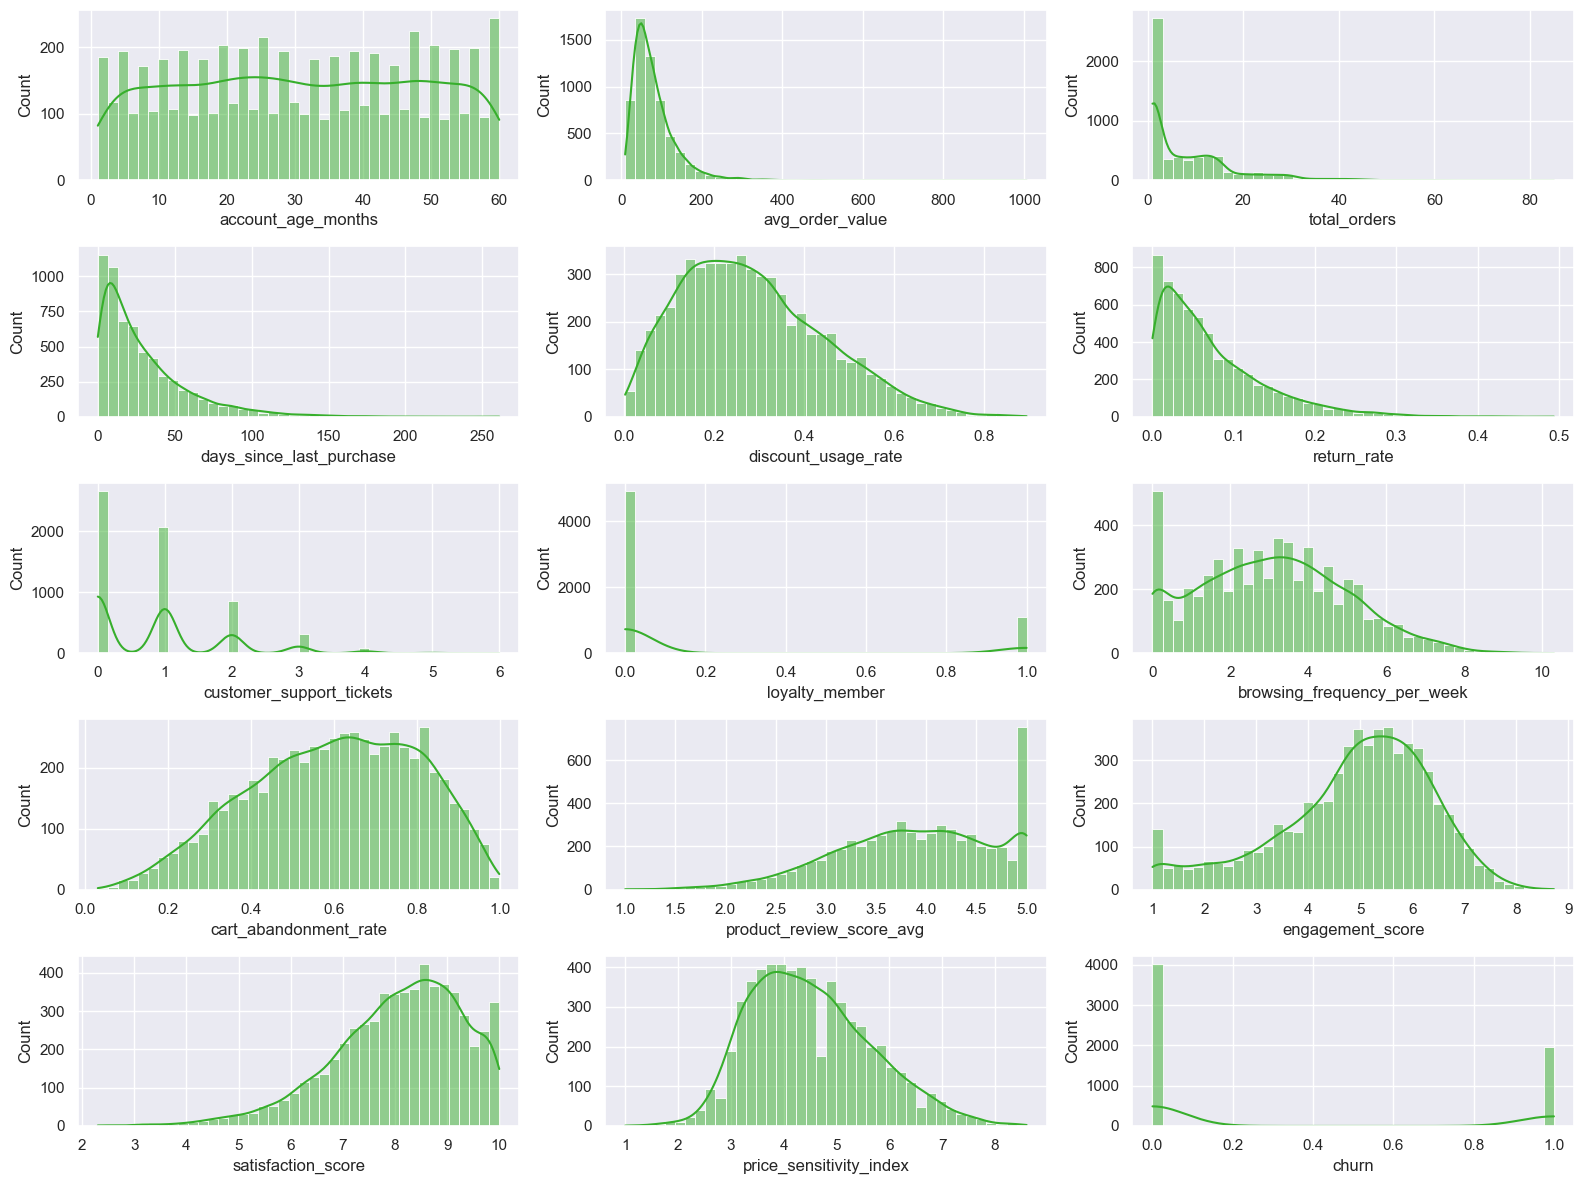

In [52]:
# EDA with plots
# in our dataSet all features have numarical features we are creating histplots and boxplot 
fig, axes= plt.subplots(5, 3, figsize= (16, 12))
axes= axes.flatten()
for i, col in enumerate(df.columns.tolist()):
    sns.histplot(
        df[col],
        bins= 40,
        ax= axes[i],
        color= "#37AF2C",
        kde= True
    )
plt.tight_layout()

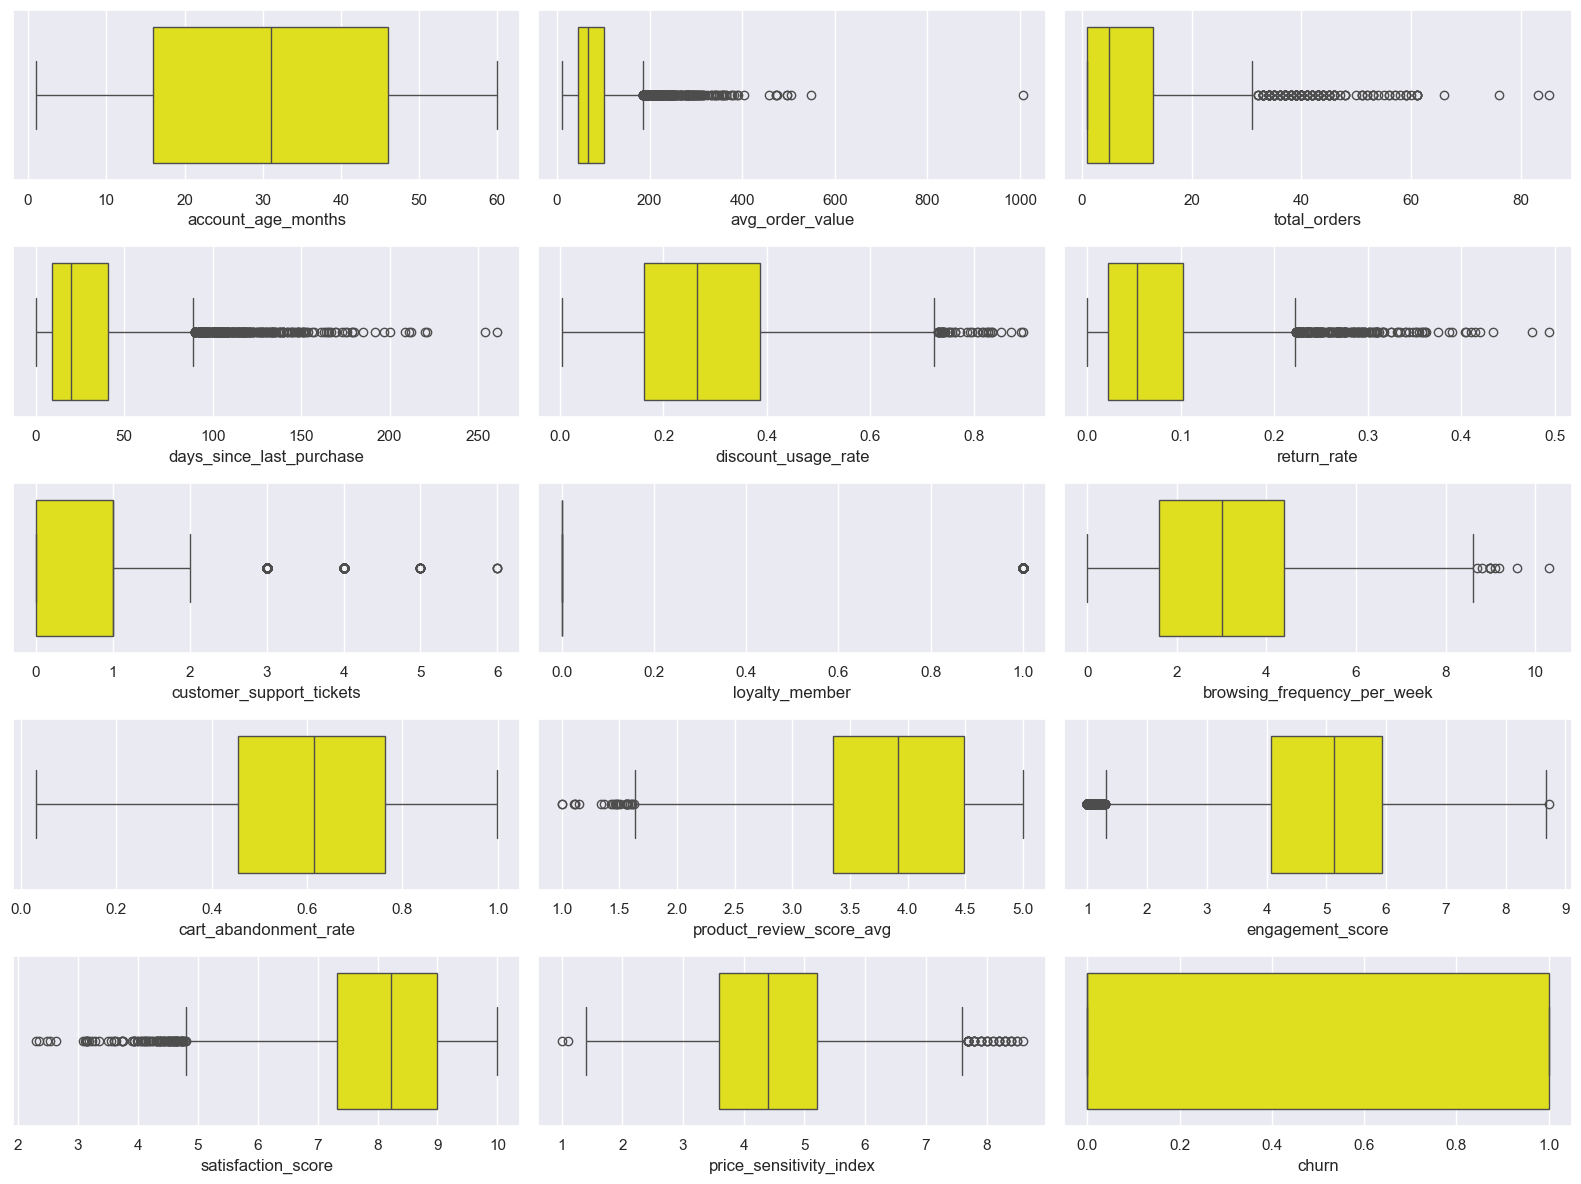

In [53]:
# EDA with plots
# BoxPlots-
fig, axes= plt.subplots(5, 3, figsize= (16, 12))
axes= axes.flatten()
for i, col in enumerate(df.columns.tolist()):
    sns.boxplot(
        x= df[col],
        ax= axes[i],
        color= "yellow"
    )
plt.tight_layout()

<Axes: xlabel='churn', ylabel='count'>

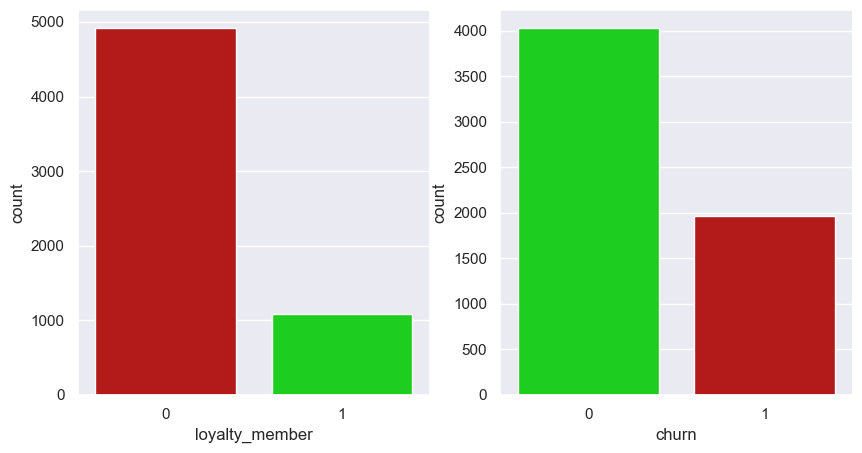

In [54]:
# count plots
plt.figure(figsize= (10, 5))
plt.subplot(1, 2, 1)
sns.countplot(x= df["loyalty_member"], palette= ["#CD0101", "#00EA04"])
plt.subplot(1, 2, 2)
sns.countplot(x= df["churn"], palette= ["#00EA04", "#CD0101"])

In [55]:
# Correlation
df.corr(numeric_only= True)["churn"].sort_values()* 100

satisfaction_score             -33.649133
engagement_score               -28.339602
product_review_score_avg       -18.367563
browsing_frequency_per_week     -9.495659
total_orders                    -5.511035
loyalty_member                  -4.464573
account_age_months              -2.457392
discount_usage_rate             -0.935604
price_sensitivity_index         -0.830971
avg_order_value                 -0.261039
cart_abandonment_rate           16.690524
return_rate                     26.401556
days_since_last_purchase        26.852384
customer_support_tickets        33.523020
churn                          100.000000
Name: churn, dtype: float64

<Axes: >

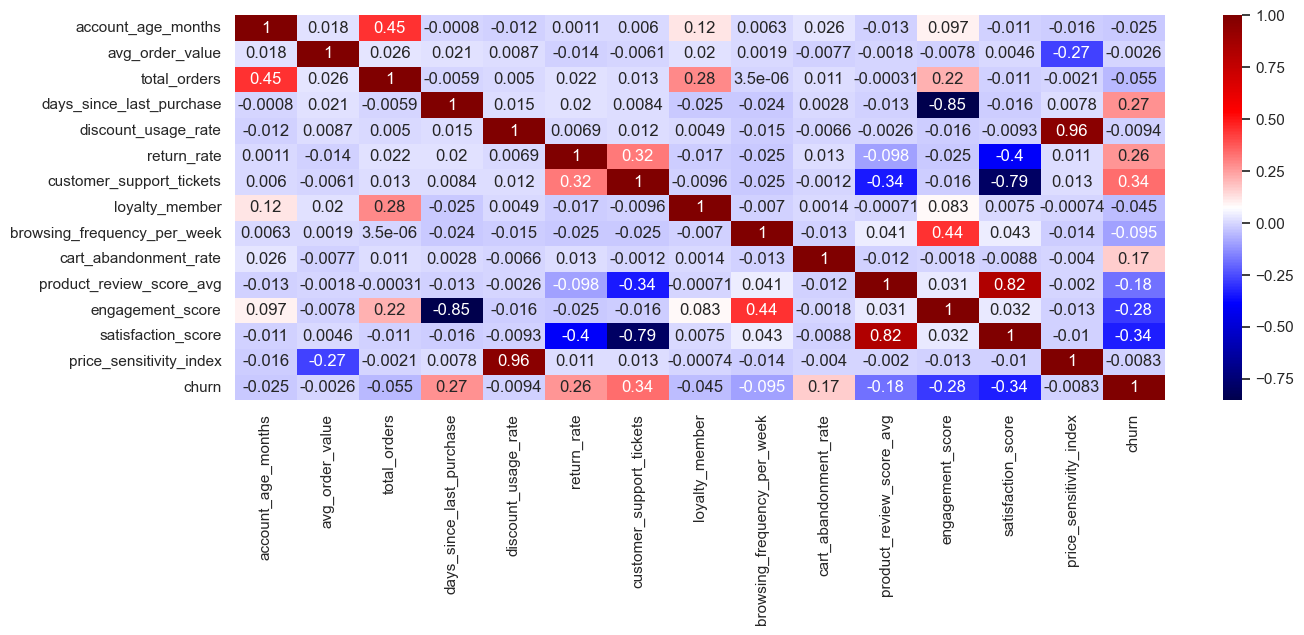

In [56]:
plt.figure(figsize= (15, 5))
sns.heatmap(df.corr(), annot= True, cmap= "seismic")

In [57]:
# after analysing this heatmap there is similer corelations of price_sensitivity_index and discount_usage_rate we shoud drop any one of these feature
# because 
# it couses overfitting in training time and another reson is both features gives same meaning

In [58]:
df.drop("discount_usage_rate", axis= 1, inplace= True)

### phase 2:
1. importing Libraries
2. Data Splitting
3. Creating Pipelines
4. Hyper parameter Tuning
5. Model Training

In [59]:
# DataSplitting
X= df.drop("churn", axis= 1)
y= df["churn"] 

In [60]:
# Importing Librarys
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
import xgboost as xgb
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score, precision_score, recall_score,confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [61]:
# DataSplitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2 , random_state=42)

In [62]:
# Creating Pipelines
cat_pipe= Pipeline(
    [
        ("fill_null", SimpleImputer(strategy= "most_frequent")),
        ("Encoding", OneHotEncoder(handle_unknown= "ignore"))
    ]
)
num_pipe= Pipeline(
    [
        ("impute", SimpleImputer(strategy= "median")),
        ("scaler", StandardScaler())
    ]
)

compose= ColumnTransformer(
    [
        ("cat_fet", cat_pipe, ["loyalty_member"]),
        ("num_fet", num_pipe, X.drop("loyalty_member", axis= 1).columns)
    ],
    remainder= "passthrough"
)

main_pipe= Pipeline(
    [
        ("process", compose),
        ("model", LogisticRegression())
    ]
)

In [63]:
# Model Training
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(random_state=42)
}

# Baseline loop chalakar pehle test karo kiski accuracy/F1 sabse high hai!
for name, model in models.items():
    main_pipe.set_params(model=model)
    main_pipe.fit(X_train, y_train)
    preds = main_pipe.predict(X_test)
    print(f"{name} -> F1 Score: {f1_score(y_test, preds):.4f}")

Logistic Regression -> F1 Score: 0.6957
KNN -> F1 Score: 0.5865
Decision Tree -> F1 Score: 0.5065
Random Forest -> F1 Score: 0.6429
XGBoost -> F1 Score: 0.6293


In [64]:
# Pasrmeter for CV
param_grid_cls= [
        {
            'model': [LogisticRegression()],
            'model__penalty': ['l1', 'l2', 'elasticnet', None],
            'model__C': [0.01, 0.1, 1, 10, 100],
            'model__solver': ['liblinear', 'saga'], # 'saga' supports all penalties
            'model__max_iter': [100, 200]
        },
        {
            'model': [KNeighborsClassifier()],
            'model__n_neighbors': [3, 5, 7, 11],
            'model__weights': ['uniform', 'distance'],
            'model__metric': ['euclidean', 'manhattan'],
            'model__p': [1, 2]
        },
        {
            "model": [DecisionTreeClassifier()],
            'model__criterion': ['gini', 'entropy', 'log_loss'],
            'model__max_depth': [None, 5, 10, 20],
            'model__min_samples_split': [2, 5, 10],
            'model__min_samples_leaf': [1, 2, 4]
        },
        {
            'model': [SVC()],
            'model__C': [0.1, 1, 10],
            'model__kernel': ['linear', 'rbf', 'poly'],
            'model__gamma': ['scale', 'auto'],
            'model__probability': [True]
        },
        {
            'model': [RandomForestClassifier()],
            'model__n_estimators': [100, 200],
            'model__max_depth': [None, 10, 20],
            'model__criterion': ['gini', 'entropy'],
            'model__max_features': ['sqrt', 'log2', None]
        },
        {
            'model': [AdaBoostClassifier()],
            'model__n_estimators': [50, 100, 200],
            'model__learning_rate': [0.01, 0.1, 1.0],
        },
        {
            'model': [GradientBoostingClassifier()],
            'model__n_estimators': [100, 200],
            'model__learning_rate': [0.01, 0.1, 0.2],
            'model__max_depth': [3, 5, 8],
            'model__subsample': [0.8, 1.0]
        }
    ]

In [65]:
# Creating OBJ for GridSearchCV
grid= GridSearchCV(main_pipe, param_grid_cls, cv= KFold(n_splits= 5, shuffle= True, random_state= 42), return_train_score= False, n_jobs= -1, verbose= 2)

In [66]:
# # Model Traing
grid.fit(X_train, y_train)

Fitting 5 folds for each of 319 candidates, totalling 1595 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model': [LogisticRegression()], 'model__C': [0.01, 0.1, ...], 'model__max_iter': [100, 200], 'model__penalty': ['l1', 'l2', ...], ...}, {'model': [KNeighborsClassifier()], 'model__metric': ['euclidean', 'manhattan'], 'model__n_neighbors': [3, 5, ...], 'model__p': [1, 2], ...}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None c

### phase 3:
1. Model Evaluvating (Predictions) 
2. Anaysing accurecy, F1 and Classification report
3. Chooseing Best model
4. Frontend With Streamlit

In [67]:
# Prediction
y_pred= grid.predict(X_test)

In [68]:
cm= confusion_matrix(y_test, y_pred)

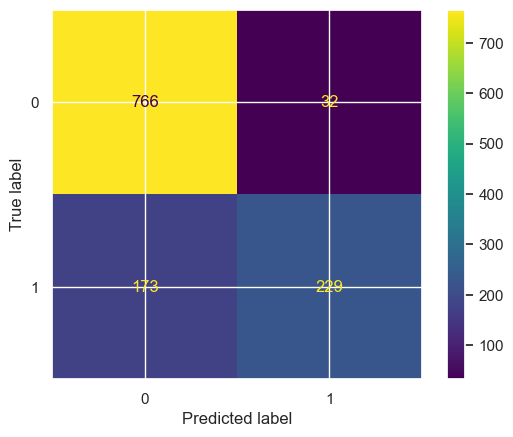

In [69]:
disp= ConfusionMatrixDisplay(confusion_matrix= cm, display_labels= grid.classes_)
disp.plot()

In [70]:
f1= round(f1_score(y_test, y_pred), 4)
prec= round(precision_score(y_test, y_pred), 4)
rec= round(recall_score(y_test, y_pred), 4)
acc= round(accuracy_score(y_test, y_pred), 4)
cls_r= classification_report(y_test, y_pred)

print(f"F1 score(with best parameters): {f1}")
print(f"recall_score(with best parameters): {rec}")
print(f"precision_score(with best parameters): {prec}")
print(f"accuresy score(with best parameters): {acc}\n")
print(f"classsification_report:\n{cls_r}")

F1 score(with best parameters): 0.6908
recall_score(with best parameters): 0.5697
precision_score(with best parameters): 0.8774
accuresy score(with best parameters): 0.8292

classsification_report:
              precision    recall  f1-score   support

           0       0.82      0.96      0.88       798
           1       0.88      0.57      0.69       402

    accuracy                           0.83      1200
   macro avg       0.85      0.76      0.79      1200
weighted avg       0.84      0.83      0.82      1200



In [71]:
# best Parameters
best_parm= grid.best_params_
for parm in best_parm.items():
    print(f"{parm[0]}: {parm[1]}")

model: LogisticRegression()
model__C: 0.1
model__max_iter: 100
model__penalty: l1
model__solver: liblinear


In [72]:
pd.DataFrame(grid.cv_results_)[["param_model", "mean_test_score", "rank_test_score"]].sort_values("rank_test_score")

,param_model,mean_test_score,rank_test_score
24,LogisticRegression(),0.821458,1
16,LogisticRegression(),0.821458,1
40,LogisticRegression(),0.820833,3
32,LogisticRegression(),0.820625,4
18,LogisticRegression(),0.820625,4
...,...,...,...
30,LogisticRegression(),NaN,300
28,LogisticRegression(),NaN,300
12,LogisticRegression(),NaN,300
6,LogisticRegression(),NaN,300


In [73]:
# after analyzing aor comfution matrix is imballanced 
# we need to balance presition and recall score
# thats why we gone using ensembel blending (Stacking) to achive balanced confutioin matrix

In [74]:
# Enasembel Techniq
from sklearn.ensemble import StackingClassifier
base_models= [
    ("lr", LogisticRegression(C= 0.1, max_iter= 100, penalty= "l1", solver= "liblinear")),
    ("AdaBoost", AdaBoostClassifier(learning_rate= 1.0, n_estimators= 200, random_state= 42)),
    ("GradientBoost", GradientBoostingClassifier(learning_rate= 0.2, max_depth= 3, n_estimators= 100, subsample= 1.0, random_state= 42))
]
{'model': RandomForestClassifier(), 'model__criterion': 'gini', 'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__n_estimators': 200}
meta_model= RandomForestClassifier(criterion= "gini", max_depth= 10, max_features= "sqrt", n_estimators= 200, random_state= 42)
stack_pipe= Pipeline(
    [
        ("process", compose),
        ("stack", StackingClassifier(
            estimators= base_models,
            final_estimator= meta_model,
            cv= KFold(n_splits= 5, shuffle= True, random_state= 42),
            passthrough= False,
            n_jobs= -1
        ))
    ]
)

In [75]:
# model_training
stack_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('process', ...), ('stack', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat_fet', ...), ('num_fet', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [76]:
stack_pred= stack_pipe.predict(X_test)
stack_rec= round(recall_score(y_test, stack_pred), 4)
stack_prec= round(precision_score(y_test, stack_pred), 4)
stack_f1= round(f1_score(y_test, stack_pred), 4)
stack_acc= round(accuracy_score(y_test, stack_pred), 4)
cls_r_stack= classification_report(y_test, stack_pred)

In [77]:
comparison= pd.DataFrame(np.array([[acc, f1, rec, prec], [stack_acc, stack_f1, stack_rec, stack_prec]]), columns= ["accuracy_score", "f1_score", "recall_score", "precision_score"]).T
comparison.columns= ["GridSearchCV (before)", "Stacking (after)"]
comparison

,GridSearchCV (before),Stacking (after)
accuracy_score,0.8292,0.8358
f1_score,0.6908,0.7141
recall_score,0.5697,0.6119
precision_score,0.8774,0.8571


In [78]:
print("before\n",cls_r,"\n\n\nafter", cls_r_stack)

before
               precision    recall  f1-score   support

           0       0.82      0.96      0.88       798
           1       0.88      0.57      0.69       402

    accuracy                           0.83      1200
   macro avg       0.85      0.76      0.79      1200
weighted avg       0.84      0.83      0.82      1200
 


after               precision    recall  f1-score   support

           0       0.83      0.95      0.88       798
           1       0.86      0.61      0.71       402

    accuracy                           0.84      1200
   macro avg       0.84      0.78      0.80      1200
weighted avg       0.84      0.84      0.83      1200



In [79]:
stack_cm= confusion_matrix(y_test, stack_pred)

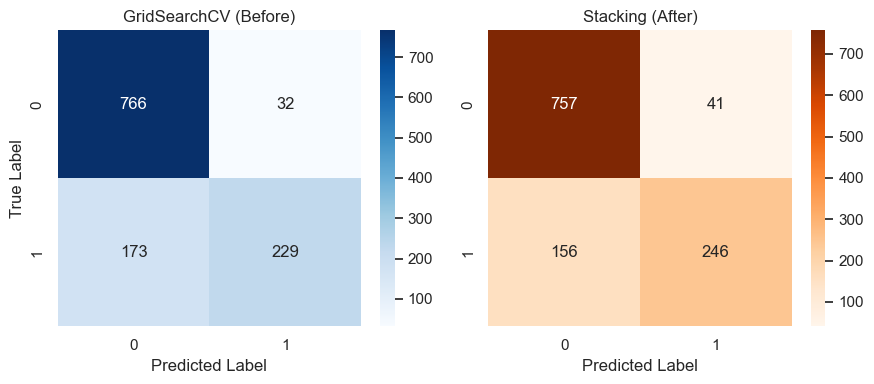

In [80]:
plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot= True, fmt='d', cmap='Blues')
plt.title("GridSearchCV (Before)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")


plt.subplot(1, 2, 2)
sns.heatmap(stack_cm, annot= True, fmt='d', cmap='Oranges')
plt.title("Stacking (After)")
plt.xlabel("Predicted Label")


plt.tight_layout()

In [81]:
# we choose the stacking approch because of balanced recall and precition score
# next step is deplyment part go to app.py file to see frontend design using AI

In [82]:
# import joblib
# joblib.dump(stack_pipe, "churn_blending_model.joblib")

In [83]:
print("Radha")

Radha
